In [13]:
%matplotlib widget
import scipp as sc
import plopp as pp
import scippneutron as scn
import scippnexus as snx
import h5py
from pathlib import Path
import numpy as np
import ipywidgets as ipw

## An simulated sample with incoherent elastic scattering and one phonon mode
The data file specified below contains simulated scattering from a sample with one incoherent elastic scattering mode,
and one phonon mode with instrument-parameter controlled slope, `sound_speed`.

A standard-McStas particle can only scatter from either the elastic mode _or_ phonon,
and this simulation splits the particles equally between the two modes.
A better approach would have been sending significantly more particles to the phonon.

The phonon FCC lattice constant $a=6.56162$ Å was chosen such that its {200} Bragg peaks (not simulated) 
would appear at 90 degree $a_4$ in the $E_f = 3.8$ meV analyzers.

The simulation was conducted as an sample orientation scan with all other parameters fixed.

| Parameter | Value | Notes |
|-----------|-------|-------|
| `sound_speed` / meV Å | 2.5 |  |
| $a_3$ / degree | 0:179 | 1-degree steps, endpoints included |
| $a_4$ / degree | 90. | all simulations have this single detector tank position |
| pulse-shaping chopper opening time  / msec | 0.2 | picked to be a realistic best-case energy-resolution |
| minimum $E_i$ / meV | 2.5 | giving a maximum of ~5.1 meV due to BIFROST's pseudo-white beam |

The simulation was started at approxmately 5:37 UTC on 14. September 2024, 
and required approximately 30 seconds per $a_3$ setting using MPI with 6 nodes.

In [2]:
datafile = "20240914/BIFROST_20240914T053723.h5"

In [3]:
from bifrost2409.config import POOCH_DATA_DIR, INTERIM_DATA_DIR
from bifrost2409.dataset import download_datafiles
download_datafiles([datafile])

2024-11-25 10:00:54.747 | INFO     | bifrost2409.config:<module>:13 - PROJ_ROOT path is: /home/g/Projects/20240914/bifrost-workflow-2409
Fetching: 100%|███████████████████████████████████| 1/1 [00:00<00:00,  4.95it/s]


### Trust the workflow, use the worflow

Now that we trust the process that we performed 'by hand' in the last two notebooks,
we can make use of the same process available through the workflow in abbreviated form
as `bifrost_single`, which _ignores_ any scan information and treats all data as a single setting.

> **Note**: Since the workflow is _intended_ for _real_ data, but our simulations need some manipulations
> you _must_ specify that this datafile `is_simulated`.

In [4]:
from ess.spectroscopy.indirect import bifrost_single
as_one = bifrost_single(POOCH_DATA_DIR / datafile, is_simulated=True)

We can get an overview of the per-pixel inelastic spectrum (but we plot it here as a function of 10% of a _tube_)

In [5]:
tube_count = 3 * 9 * 5 * 10
as_one['events'].bin(energy_transfer=100).hist(
    energy_transfer=sc.linspace(start=-1.7, stop=1.7, num=50, dim='energy_transfer', unit='meV'),
    detector_number=tube_count,
).plot(norm='log')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

/home/g/Projects/20240914/bifrost-workflow-2409/new_venv/lib/python3.11/site-packages/plopp/backends/matplotlib/canvas.py:140: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


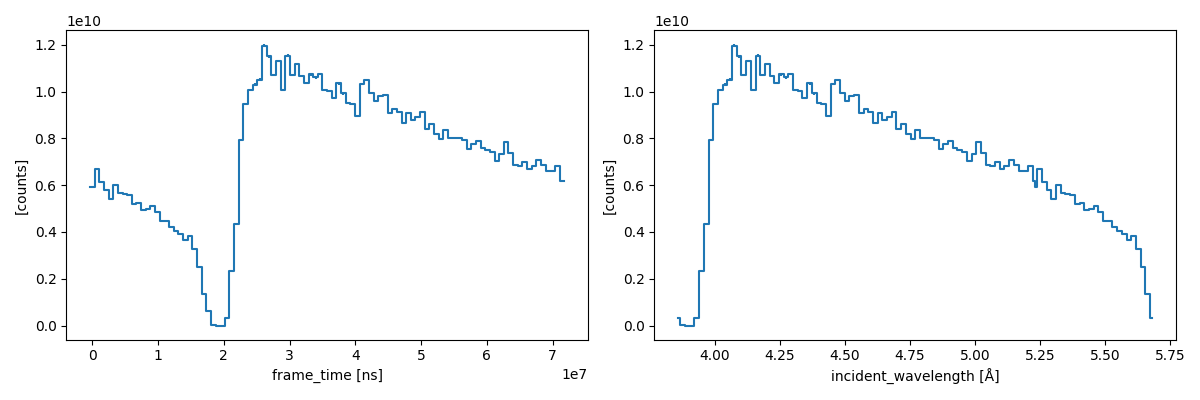

In [6]:
as_one['norm_monitor'].plot() + as_one['wavelength_monitor'].plot()

In [8]:
list(as_one.keys())

['triplet_events',
 'events',
 'norm_monitor',
 'sample_detector_flight_time',
 'analyzers',
 'wavelength_monitor',
 'norm_events']

In [37]:
det_et = as_one['triplet_events'].transform_coords(event_time=lambda event_time_offset, event_time_zero: event_time_offset+event_time_zero)
det_et_bins = det_et.bin(event_time=180)
det_et_bins

<scipp.DataArray>
Dimensions: Sizes[detector_number:13500, event_time:180, ]
Coordinates:
* detector_number             int64        <no unit>  (detector_number)  [1, 2, ..., 13499, 13500]
* event_time              datetime64             [ns]  (event_time [bin-edge])  [2024-09-14T05:38:48.689437184, 2024-09-14T05:39:26.770682368, ..., 2024-09-14T07:32:25.232334592, 2024-09-14T07:33:03.313579776]
* position                  vector3              [m]  (detector_number)  [(0.446308, -1.11076, 0.519975), (0.447766, -1.11076, 0.518223), ..., (1.54932, -1.55744, -1.50975), (1.54724, -1.55744, -1.5122)]
* x_pixel_offset            float64              [m]  (detector_number)  [-0.014, -0.014, ..., 0.014, 0.014]
* y_pixel_offset            float64              [m]  (detector_number)  [0.112822, 0.110543, ..., -0.156137, -0.159356]
Data:
                          DataArrayView        <no unit>  (detector_number, event_time)  binned data: dim='event', content=DataArray(
          dims=(event: 11545262),
          data=float32[counts],
          coords={'event_time_offset':int32[ns], 'event_time_zero':datetime64[ns],
                  'frame_time':float64[ns], 'event_time':datetime64[ns]})

In [47]:
def intensity(data=None, angle=0):
    return sc.DataArray(data=data['event_time', angle].hist(detector_number=13500).data, coords={'pos': data.coords['position']})
    

In [57]:
data_node = pp.Node(det_et_bins)
play = ipw.Play(value=0, min=0, max=det_et_bins.sizes['event_time'], step=1, interval=100, description='Play events', disabled=False)
play_node = pp.widget_node(play)
slider = ipw.IntSlider(min=0, max=det_et_bins.sizes['event_time'], readout=False)
ipw.jslink((play, 'value'), (slider, 'value'))

slice_node = pp.Node(intensity, data=data_node, angle=play_node)
pp.show_graph(slice_node)

camera = pp.Camera(position=sc.vector([0, 0, 0], unit='m'), look_at=sc.vector([1., -1.2, 0], unit='m'))
fig = pp.scatter3d(slice_node, pos='pos', pixel_size=0.01, cbar=True, cmap='inferno', camera=camera)

In [58]:
display(fig)
display(ipw.HBox([play, slider]))

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

In [53]:
play.value

180